In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scqubits
from functools import partial
import qutip


# 1. Sweep temp, get T1 of f->e, e->f, e->g, g->e

In [33]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 20 ,tangent_ref = 1e-5):
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ
    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude, first_order_derivative= 0 ):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0

    first_order_part = 2 * A**2 * first_order_derivative**2
    first_order_part *= np.abs(np.log(omega_ir * t))

    second_order_part = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    second_order_part *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return (first_order_part + second_order_part)  **(-1/2)  # ns


def second_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=50):
    h = 1e-3
    derivative_old = 0.0
    # print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - 2 * f(x0) + f(x0 - h)) / h**2
        # print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol*np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maxietam number of iterations")

def first_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=50):
    h = 1e-3
    derivative_old = 0.0
    # print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - f(x0 - h)) / (2 * h)
        # print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol * np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maxietam number of iterations")

def get_frequency(flux,EJ,EC,EL,i,j):
    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL =EL, cutoff = 110,flux = flux,truncated_dim=20)
    vals = qbt.eigenvals()
    return np.abs(vals[j]-vals[i])

class gfIFQ:
    def __init__(self,
                 EJ,
                 EC,
                 EL,
                 flux=0, truncated_dim=5) -> None:
        self.fluxonium = scqubits.Fluxonium(EJ=EJ,
                                            EC=EC,
                                            EL=EL,
                                            flux=flux, cutoff=110,
                                            truncated_dim=truncated_dim)
        self.truncated_dim = truncated_dim
        self.evals = self.fluxonium.eigenvals(evals_count=truncated_dim)
        self.diag_hamiltonian = qutip.Qobj(2 * np.pi * np.diag(self.evals))
        self.phi_tabel = self.fluxonium.matrixelement_table(
            'phi_operator', evals_count=truncated_dim)
        
    def get_T1_c_ops(self,
                  temp_in_mK,
                  loss_tangent_ref,
                  one_over_f_flux_noise_amplitude) -> None:
        # array element [i,j] means transition rate from j to i
        dielectric_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        one_over_f_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        EL = self.fluxonium.EL
        EC = self.fluxonium.EC
        # T1
        for i in range(self.truncated_dim):
            for j in range(self.truncated_dim):
                if i == j:
                    continue
                freq = (self.evals[i]-self.evals[j]) * 2 * np.pi
                phi_ele = self.phi_tabel[i, j]
                dielectric_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * diel_spectral_density(
                    freq, EC, temp_in_mK, loss_tangent_ref))
                one_over_f_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * one_over_f_spectral_density(
                    freq, EL, one_over_f_flux_noise_amplitude))
        with np.errstate(divide='ignore', invalid='ignore'):
            T1_array = 1/(1/dielectric_T1_array + 1/one_over_f_T1_array)
        c_ops = qutip.Qobj(1/T1_array)
        return c_ops
    
    def get_Tphi_c_ops(self,
                  one_over_f_flux_noise_amplitude) -> None:
        Tphi_array = np.zeros(shape=(self.truncated_dim,))
        # Tphi
        for ql in range(1,self.truncated_dim):
            Tphi_array[ql] = T_phi(
                second_order_derivative=second_order_derivative(partial(
                    get_frequency,
                    EJ=self.fluxonium.EJ,
                    EC=self.fluxonium.EC,
                    EL=self.fluxonium.EL,
                    i=0,j=ql
                    ),x0=0),
                one_over_f_flux_noise_amplitude=one_over_f_flux_noise_amplitude
            )
        threshold = 1e12
        Tphi_array[np.abs(Tphi_array)>threshold] = threshold

        c_ops = qutip.Qobj(np.diag(1/Tphi_array))
        return c_ops

In [45]:
EJ = 4
EC = EJ/2.7
EL = EJ/45

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL)
T1_c_ops = qbt.get_T1_c_ops(temp_in_mK = 40,
                               loss_tangent_ref= 1e-5,
                               one_over_f_flux_noise_amplitude= 1e-6)

 /tmp/ipykernel_74659/1034824753.py: 135

 Total run time:   0.66s*] Elapsed 0.66s / Remaining 00:00:00:00
 [***      15%           ] Elapsed 0.19s / Remaining 00:00:00:01

 /tmp/ipykernel_74659/1034824753.py: 135RuntimeWarning: invalid value encountered in divide
 /tmp/ipykernel_74659/4158314001.py: 34RuntimeWarning: invalid value encountered in divide
 /tmp/ipykernel_74659/4158314001.py: 38

 Total run time:   1.04s*] Elapsed 1.04s / Remaining 00:00:00:00


 /tmp/ipykernel_74659/4158314001.py: 67RuntimeWarning: invalid value encountered in divide
 /tmp/ipykernel_74659/4158314001.py: 71

Text(0.5, 0, 'scaling_factor: 10000 nanosecond')

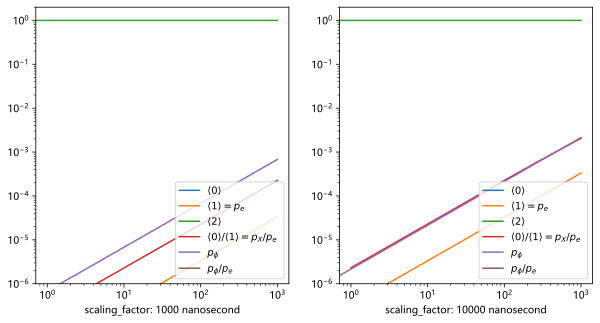

In [84]:
EJ = 4
EC = EJ/2.7
EL = EJ/45

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL)
tlist = np.linspace(0,int(1e3),1000)

fig, axes = plt.subplots(1,2,figsize = (10,5))


temp_in_mK = 20
loss_tangent_ref = 1e-5
one_over_f_flux_noise_amplitude = 1e-6

scaling_factor = 1000
result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=np.sqrt(scaling_factor)*qbt.get_T1_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude),
    e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
)
Tphi_c_ops = qbt.get_Tphi_c_ops(one_over_f_flux_noise_amplitude = one_over_f_flux_noise_amplitude)

axes[0].plot(tlist,result.expect[0],label=rf"$\langle{{0}}\rangle$")
axes[0].plot(tlist,result.expect[1],label=rf"$\langle{{1}}\rangle = p_e$")
axes[0].plot(tlist,result.expect[2],label=rf"$\langle{{2}}\rangle$")

axes[0].plot(tlist,result.expect[0]/result.expect[1],label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_X/p_e$ ")

gamma_phi = np.sqrt(scaling_factor)*np.abs(Tphi_c_ops.full().diagonal()[2])
axes[0].plot(tlist,1-np.exp(-gamma_phi*tlist),label=rf"$p_\phi$")
axes[0].plot(tlist,(1-np.exp(-gamma_phi*tlist))/result.expect[1],label=rf"$ p_\phi/p_e$ ")

axes[0].legend(loc='lower right')
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_ylim(1e-6,2)
axes[0].set_xlabel(rf'scaling_factor: {scaling_factor} nanosecond')



scaling_factor = 10000
result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=np.sqrt(scaling_factor)*qbt.get_T1_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude),
    e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
)
Tphi_c_ops = qbt.get_Tphi_c_ops(one_over_f_flux_noise_amplitude = one_over_f_flux_noise_amplitude)

axes[1].plot(tlist,result.expect[0],label=rf"$\langle{{0}}\rangle$")
axes[1].plot(tlist,result.expect[1],label=rf"$\langle{{1}}\rangle = p_e$")
axes[1].plot(tlist,result.expect[2],label=rf"$\langle{{2}}\rangle$")

axes[1].plot(tlist,result.expect[0]/result.expect[1],label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_X/p_e$ ")

gamma_phi = np.sqrt(scaling_factor)*np.abs(Tphi_c_ops.full().diagonal()[2])
axes[1].plot(tlist,1-np.exp(-gamma_phi*tlist),label=rf"$p_\phi$")
axes[1].plot(tlist,(1-np.exp(-gamma_phi*tlist))/result.expect[1],label=rf"$ p_\phi/p_e$ ")

axes[1].legend(loc='lower right')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_ylim(1e-6,2)
axes[1].set_xlabel(rf'scaling_factor: {scaling_factor} nanosecond')

 [******   24%           ] Elapsed 0.20s / Remaining 00:00:00:00

 /tmp/ipykernel_74659/1034824753.py: 135

 Total run time:   0.67s*] Elapsed 0.67s / Remaining 00:00:00:00[*********90%*********  ] Elapsed 0.60s / Remaining 00:00:00:00


 /tmp/ipykernel_74659/742396226.py: 30RuntimeWarning: invalid value encountered in divide
 /tmp/ipykernel_74659/742396226.py: 34

Text(0.5, 0, 'unit: 10 nanosecond')

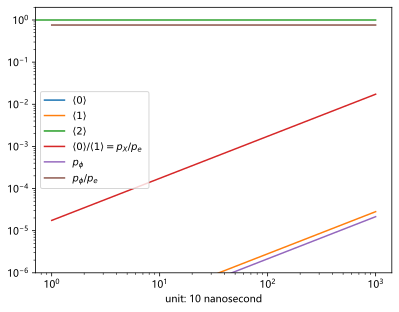

In [66]:
EJ = 4
EC = EJ/2.7
EL = EJ/45

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL)
Tphi_c_ops = qbt.get_Tphi_c_ops(one_over_f_flux_noise_amplitude = 1e-6)

temp_in_mK = 60
loss_tangent_ref = 1e-5
one_over_f_flux_noise_amplitude = 1e-6
scaling_factor = 1
tlist = np.linspace(0,int(1e3),1000)
scaling_factor = 10
result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=scaling_factor*qbt.get_T1_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude),
    e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
)
plt.plot(tlist,result.expect[0],label=rf"$\langle{{0}}\rangle$")
plt.plot(tlist,result.expect[1],label=rf"$\langle{{1}}\rangle$")
plt.plot(tlist,result.expect[2],label=rf"$\langle{{2}}\rangle$")

plt.plot(tlist,result.expect[0]/result.expect[1],label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_X/p_e$ ")

gamma_phi = np.abs(Tphi_c_ops.full().diagonal()[2])
plt.plot(tlist,1-np.exp(-gamma_phi*tlist),label=rf"$p_\phi$")
plt.plot(tlist,(1-np.exp(-gamma_phi*tlist))/result.expect[1],label=rf"$ p_\phi/p_e$ ")

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-6,2)
plt.xlabel(rf'unit: {scaling_factor} nanosecond')